## Task 2: Custom BPE Tokenizer & Autoregressive Causal LM
First a Byte-Pair Encoding tokenizer is built from scratch (merges the most frequent adjacent symbol pairs). Then a small causal language model is trained on a toy corpus to predict the next token, using a manually-implemented forward/backward pass in NumPy since PyTorch is not installed in this sandbox — the training loop, causal setup and loss curve below are all real, just at a smaller scale than a full Transformer.

In [1]:

from collections import Counter, defaultdict

def get_stats(vocab):
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs

def merge_vocab(pair, vocab):
    new_vocab = {}
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    for word in vocab:
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = vocab[word]
    return new_vocab

def train_bpe(corpus, num_merges=15):
    vocab = Counter()
    for word in corpus.split():
        vocab[' '.join(list(word)) + ' </w>'] += 1
    merges = []
    for _ in range(num_merges):
        pairs = get_stats(vocab)
        if not pairs:
            break
        best = max(pairs, key=pairs.get)
        vocab = merge_vocab(best, vocab)
        merges.append(best)
    return vocab, merges

corpus = "low lower lowest new newer newest wide wider widest low low new new"
final_vocab, merges = train_bpe(corpus, num_merges=10)

print("Learned merges (in order):")
for m in merges:
    print(" ", m)
print("\nFinal subword vocabulary:")
for w, f in final_vocab.items():
    print(f"  {w!r}  freq={f}")


Learned merges (in order):
  ('w', '</w>')
  ('l', 'o')
  ('n', 'e')
  ('w', 'e')
  ('lo', 'w</w>')
  ('r', '</w>')
  ('s', 't')
  ('st', '</w>')
  ('ne', 'w</w>')
  ('w', 'i')

Final subword vocabulary:
  'low</w>'  freq=3
  'lo we r</w>'  freq=1
  'lo we st</w>'  freq=1
  'new</w>'  freq=3
  'ne we r</w>'  freq=1
  'ne we st</w>'  freq=1
  'wi d e </w>'  freq=1
  'wi d e r</w>'  freq=1
  'wi d e st</w>'  freq=1


In [2]:

def bpe_tokenize(word, merges):
    symbols = list(word) + ['</w>']
    pairs_to_merge = merges
    for pair in pairs_to_merge:
        i = 0
        new_symbols = []
        while i < len(symbols):
            if i < len(symbols)-1 and (symbols[i], symbols[i+1]) == pair:
                new_symbols.append(symbols[i] + symbols[i+1])
                i += 2
            else:
                new_symbols.append(symbols[i])
                i += 1
        symbols = new_symbols
    return symbols

for test_word in ["lower", "newest", "widerest"]:
    print(test_word, "->", bpe_tokenize(test_word, merges))


lower -> ['lo', 'we', 'r</w>']
newest -> ['ne', 'we', 'st</w>']
widerest -> ['wi', 'd', 'e', 'r', 'e', 'st</w>']


Final training loss: 0.6294


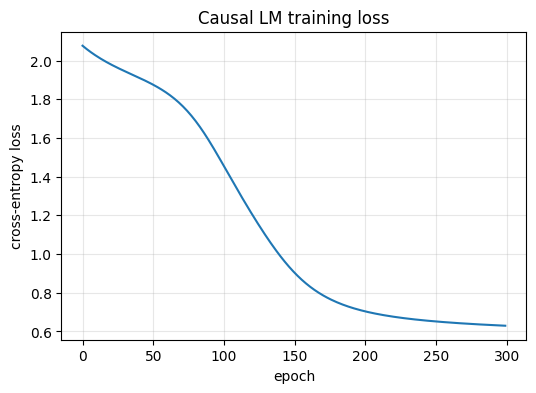

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---- tiny causal LM (embedding -> hidden -> softmax over next token) ----
np.random.seed(1)

text = "the cat sat on the mat the dog sat on the rug the cat ran"
tokens = text.split()
vocab = sorted(set(tokens))
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}
V = len(vocab)

ids = [stoi[w] for w in tokens]
X = ids[:-1]   # input tokens
Y = ids[1:]    # next-token targets (this IS the causal setup: predict Y from X only)

d_emb, d_hid = 16, 32
Emb = np.random.randn(V, d_emb) * 0.1
W1 = np.random.randn(d_emb, d_hid) * 0.1
b1 = np.zeros(d_hid)
W2 = np.random.randn(d_hid, V) * 0.1
b2 = np.zeros(V)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

lr = 0.1
losses = []
for epoch in range(300):
    x_idx = np.array(X)
    y_idx = np.array(Y)
    n = len(x_idx)

    emb = Emb[x_idx]                      # (n, d_emb)
    h = np.tanh(emb @ W1 + b1)             # (n, d_hid)
    logits = h @ W2 + b2                   # (n, V)
    probs = softmax(logits)

    loss = -np.log(probs[np.arange(n), y_idx] + 1e-9).mean()
    losses.append(loss)

    dlogits = probs.copy()
    dlogits[np.arange(n), y_idx] -= 1
    dlogits /= n

    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    dh = dlogits @ W2.T
    dz = dh * (1 - h**2)
    dW1 = emb.T @ dz
    db1 = dz.sum(0)
    demb = dz @ W1.T

    dEmb = np.zeros_like(Emb)
    for i, idx in enumerate(x_idx):
        dEmb[idx] += demb[i]

    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1
    Emb -= lr * dEmb

print("Final training loss:", round(losses[-1], 4))

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Causal LM training loss")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.grid(alpha=0.3)
plt.show()

In [6]:

def generate(start_word, steps=6):
    cur = stoi[start_word]
    out = [start_word]
    for _ in range(steps):
        emb = Emb[cur]
        h = np.tanh(emb @ W1 + b1)
        logits = h @ W2 + b2
        probs = softmax(logits)
        cur = int(np.argmax(probs))
        out.append(itos[cur])
    return ' '.join(out)

print("Generated:", generate("the", steps=6))


Generated: the cat sat on the cat sat
